In [ ]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

# Установка зависимостей
!pip install centpy pandas matplotlib seaborn scienceplots

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 661, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 661 (delta 35), reused 67 (delta 32), pack-reused 537 (from 2)
Receiving objects: 100% (661/661), 62.40 MiB | 19.54 MiB/s, done.
Resolving deltas: 100% (294/294), done.
/content/diploma_centpy_parallelization_py/jax_centpy/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [ ]:
!git clone https://github.com/tumaer/JAXFLUIDS.git
!pip install -e JAXFLUIDS

Cloning into 'JAXFLUIDS'...
remote: Enumerating objects: 2563, done.
remote: Counting objects: 100% (689/689), done.
remote: Compressing objects: 100% (228/228), done.
remote: Total 2563 (delta 539), reused 510 (delta 461), pack-reused 1874 (from 2)
Receiving objects: 100% (2563/2563), 13.19 MiB | 16.95 MiB/s, done.
Resolving deltas: 100% (1474/1474), done.
Obtaining file:///content/diploma_centpy_parallelization_py/jax_centpy/JAXFLUIDS
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jaxfluids (pyproject.toml) ... done
  Created wheel for jaxfluids: filename=jaxfluids-0.2.1-0.editable-py3-none-any.whl size=4993 sha256=6a95bf29f3c1a9d2fc0c98d5e96d81d744f042aefdfc3891d39bb0216ae3bd0b
  Stored in directory: /tmp/pip-ephem-wheel-cache-rue3ssx5/wheels/0d/f5/f7/36c7ba3191fe532ed59d9727c10bd83ddce132ae2a04111c95

In [ ]:
import os
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from google.colab import files
from typing import Callable, NamedTuple

from core import Pars2d, Equation2d, Pars1d, Equation1d
from solver import Solver1d, FastSolver1d, FastSolverWithAllLayersWithoutExtends1d
from boundaries import periodic_bc_2d, neumann_bc_2d, dirichlet_riemann_bc_2d, periodic_bc, wall_bc_1d, neumann_bc
from equations import make_euler_riemann_2d, make_euler_isentropic_vortex_2d, make_burgers_1d
from schemes import compute_rhs_sd2_2d
from limiters import monotonized_central, minmod
from richardson import self_convergence_analysis

In [ ]:
def make_modified_sod(gamma=1.4, alpha: float = 0.1) -> Equation1d:
    def compute_pressure(q):
        rho = q[..., 0]
        u = q[..., 1] / rho
        E = q[..., 2]
        return (gamma - 1.0) * (E - 0.5 * rho * u**2)

    def flux(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        E = q[..., 2]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = compute_pressure(q)
        return jnp.stack([rhou, rhou * u + p, u * (E + p)], axis=-1)

    def spectral_radius(q):
        rho = q[..., 0]
        rhou = q[..., 1]
        rhosafe = jnp.maximum(rho, 1e-10)
        u = rhou / rhosafe
        p = jnp.maximum(compute_pressure(q), 1e-10)
        c = jnp.sqrt(gamma * p / rhosafe)
        a = jnp.abs(u) + c
        return a[..., None]

    def initial_data(x):
        # Невозмущенный газ
        rho_0, p_0 = 1.0, 1.0

        # Состояние за ударной волной (по Ренкину-Гюгонио для M=2)
        rho_R = 2.66666666667
        p_R = 4.5
        u_R = -1.47901994677

        # Границы областей
        x_0 = 0.3
        x_1 = 0.5
        x_sw = 0.8

        # Кусочно-постоянное распределение плотности
        rho = jnp.where(x < x_0, rho_0,
                jnp.where(x <= x_1, alpha * rho_0,
                jnp.where(x < x_sw, rho_0, rho_R)))

        # Распределение скорости (движется только газ за фронтом УВ)
        u = jnp.where(x < x_sw, 0.0, u_R)

        # Распределение давления
        p = jnp.where(x < x_0, p_0,
                jnp.where(x <= x_1, p_0,
                jnp.where(x < x_sw, p_0, p_R)))

        E = p / (gamma - 1.0) + 0.5 * rho * u**2
        return jnp.stack([rho, rho * u, E], axis=-1)

    def mixed_bc(u, n_ghost):
        # Левая граница: условия Неймана (нулевой градиент / свободный выход волны)
        # Повторяем значения из первой внутренней ячейки (index 0) n_ghost раз.
        left_ghost = jnp.repeat(u[:1], n_ghost, axis=0)

        # Правая граница: непротекание (твердая стенка)
        # Зеркальное отражение плотности и энергии, но смена знака для импульса (u[:, 1]).
        right_ghost = u[-n_ghost:][::-1]
        right_ghost = right_ghost.at[:, 1].set(-right_ghost[:, 1])

        # Склеиваем фиктивные ячейки с основной расчетной областью
        return jnp.concatenate([left_ghost, u, right_ghost], axis=0)

    return Equation1d(
        flux=flux,
        spectral_radius=spectral_radius,
        initial_data=initial_data,
        boundary_handler=mixed_bc,  # Подключаем наши новые смешанные условия
        name="Modified Sod (Left: Neumann, Right: Wall)"
    )

In [ ]:
# Инициализация уравнения и параметров
eqn = make_modified_sod()
pars = Pars1d(x_init=0.0, x_final=1.0, t_final=0.4, dt_out=0.2, J=400, cfl=0.45)
solver = FastSolverWithAllLayersWithoutExtends1d(pars, eqn, scheme_name='fd2', limiter_name="minmod")

print("Запуск расчёта...")
t0 = time.time()
sol = solver.solve()
t1 = time.time()
print(f"\n[GPU JAX] Чистое время выполнения: {t1 - t0:.4f} секунд")
print("Расчёт успешно завершён!")

# Извлечение результатов
x_num = np.array(sol["x"])
t_num = np.array(sol["t"])
q_num = np.array(sol["u_n"])

# Декодирование консервативных переменных в примитивные
rho_num = q_num[..., 0]
u_num = q_num[..., 1] / q_num[..., 0]
p_num = 0.4 * (q_num[..., 2] - 0.5 * rho_num * u_num**2)

Запуск расчёта...

[GPU JAX] Чистое время выполнения: 1.9256 секунд
Расчёт успешно завершён!


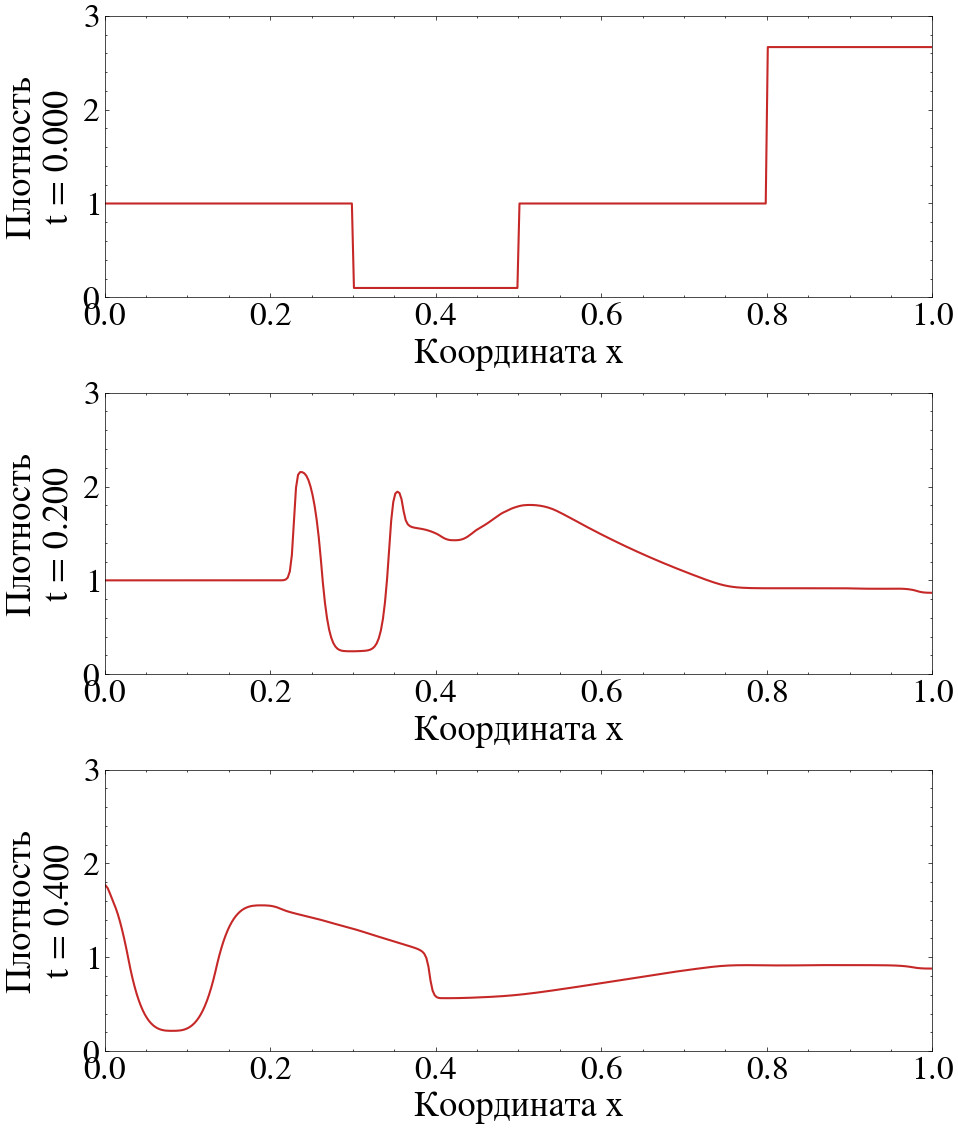

Сохранено: rho_evolution.png


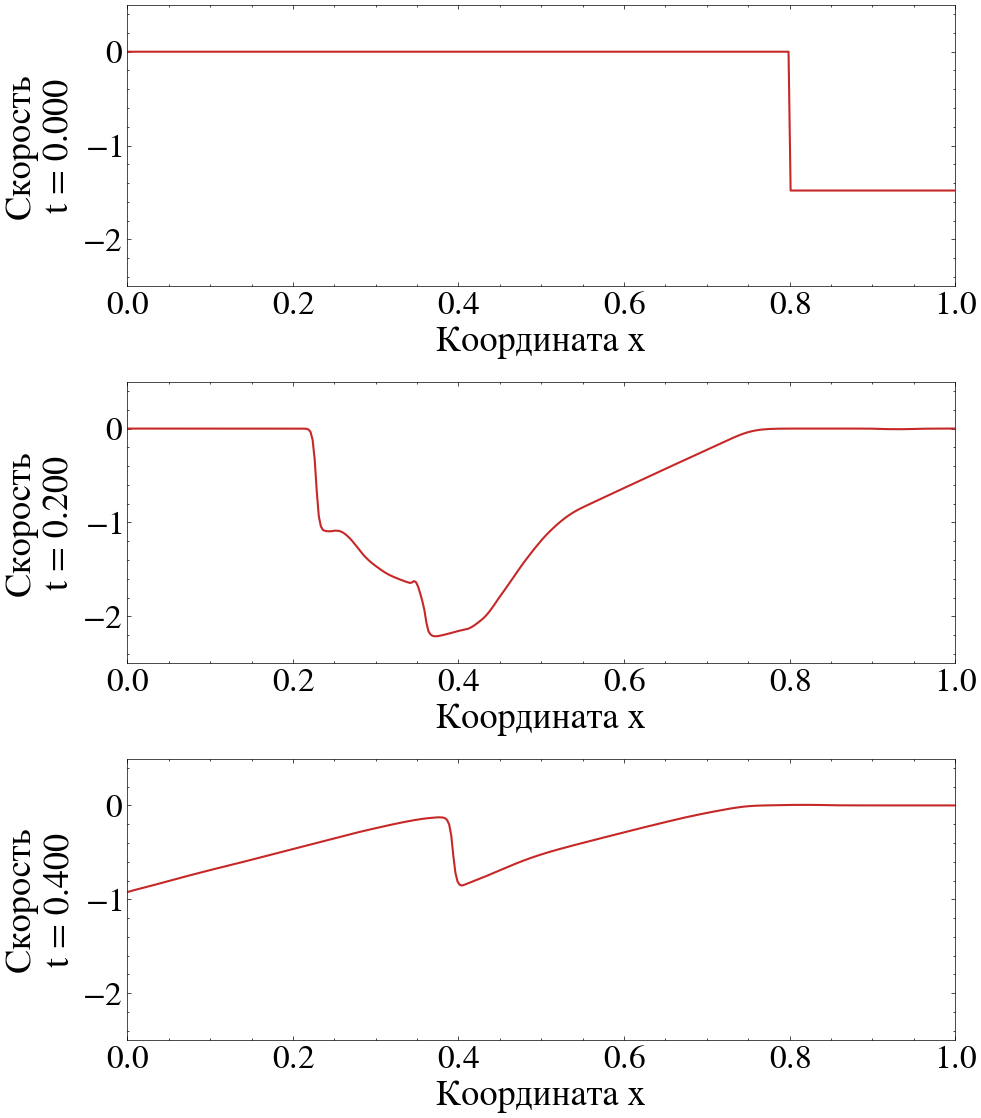

Сохранено: u_evolution.png


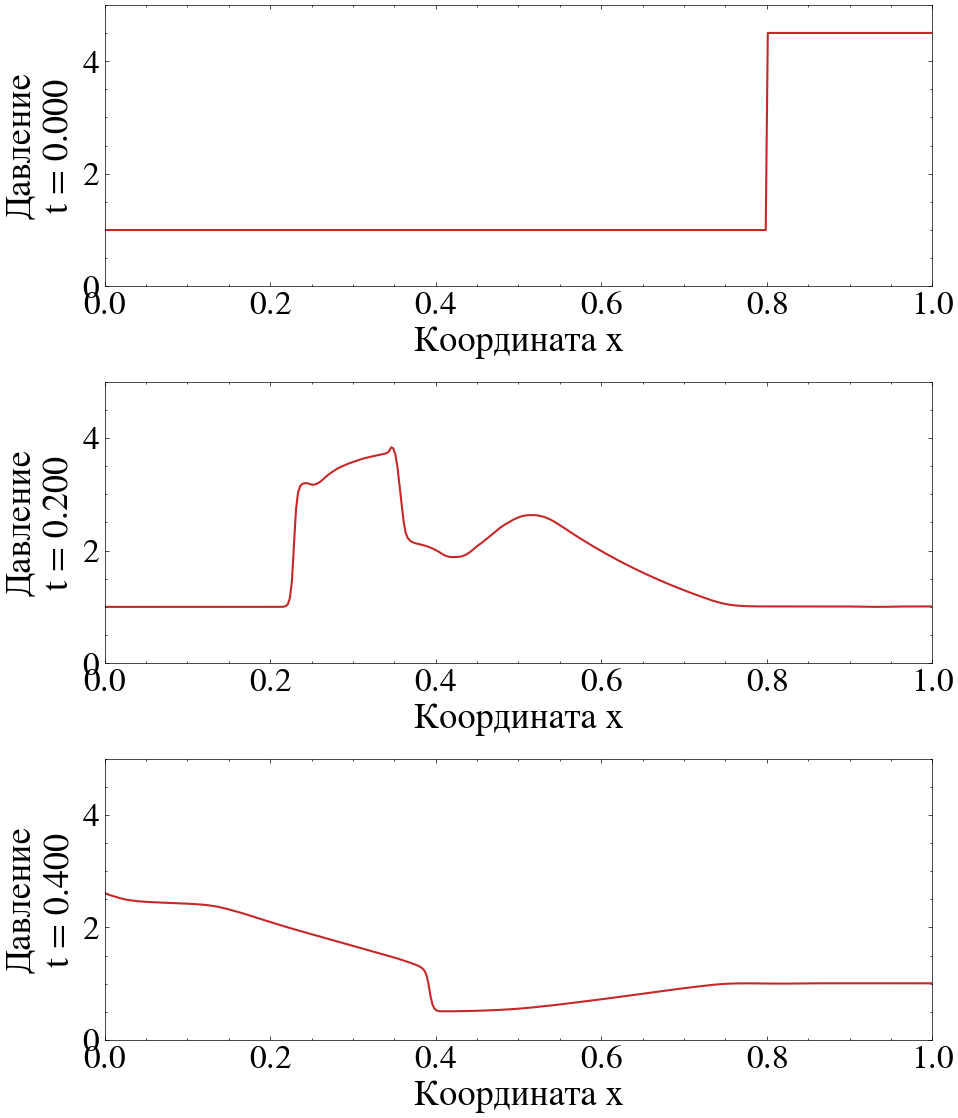

Сохранено: p_evolution.png


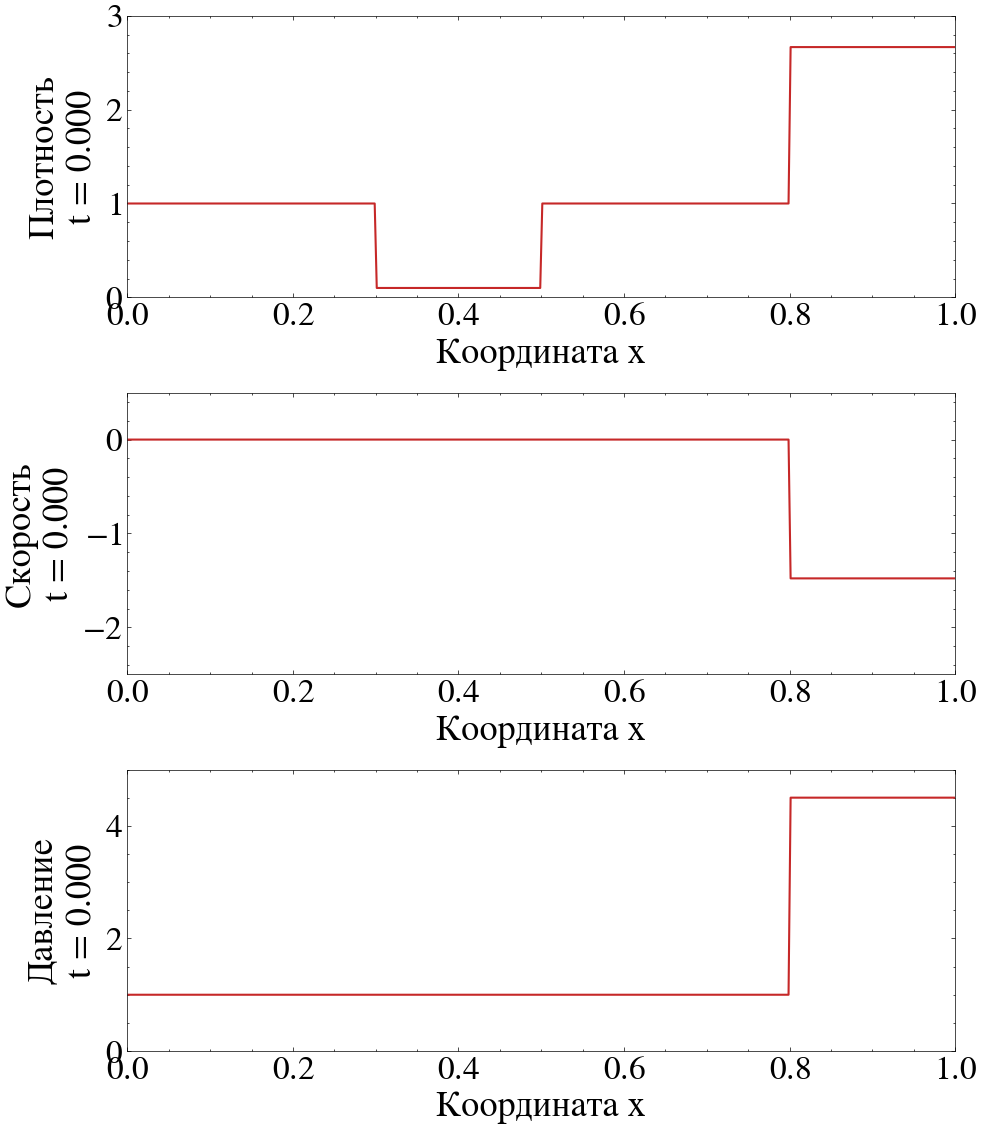

Сохранено: combined_final_state.png


In [ ]:
import scienceplots
import matplotlib.pyplot as plt

plt.style.use(['science', 'no-latex'])

# Индексы трёх моментов времени
idx_start = 0
idx_mid   = len(t_num) // 2
idx_end   = len(t_num) - 1

time_indices = [idx_start, idx_mid, idx_end]

# Настройки для каждой переменной
variables = [
    {'data': rho_num, 'ylabel': 'Плотность', 'ylim': (0.0, 3.0),  'color': '#C62828'},
    {'data': u_num,   'ylabel': 'Скорость',   'ylim': (-2.5, 0.5), 'color': '#C62828'},
    {'data': p_num,   'ylabel': 'Давление',   'ylim': (0.0, 5.0),  'color': '#C62828'},
]
filenames = ['rho_evolution.png', 'u_evolution.png', 'p_evolution.png']

# === 1. Графики эволюции каждой переменной во времени ===
for var, fname in zip(variables, filenames):
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))
    fig.tight_layout(pad=5.0)

    for row, idx in enumerate(time_indices):
        ax = axes[row]
        ax.plot(x_num, var['data'][idx], color=var['color'], linewidth=1.5)
        ax.set_xlim(0, 1)
        ax.set_ylim(*var['ylim'])
        ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx]:.3f}", fontsize=26)

        # Теперь ось x подписывается и отображается на каждом графике
        ax.set_xlabel('Координата x', fontsize=26)
        ax.tick_params(axis='both', labelsize=24)

    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Сохранено: {fname}')


# === 2. Сводный график всех переменных для конечного момента времени ===
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.tight_layout(pad=5.0)
fname_combined = 'combined_final_state.png'

for i, var in enumerate(variables):
    ax = axes[i]
    # Используем данные только для начального момента времени (idx_start)
    ax.plot(x_num, var['data'][idx_start], color=var['color'], linewidth=1.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(*var['ylim'])
    ax.set_ylabel(f"{var['ylabel']}\nt = {t_num[idx_start]:.3f}", fontsize=26)

    # Подписи оси x для каждого подграфика
    ax.set_xlabel('Координата x', fontsize=26)
    ax.tick_params(axis='both', labelsize=24)

fig.savefig(fname_combined, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Сохранено: {fname_combined}')

In [ ]:
import json
import numpy as np

# ============================================================
# 1. НАСТРОЙКА РАСЧЁТА (case_setup)
# ============================================================
general = {
    "case_name": "modified_sod_shocktube_neumann",
    "end_time": 0.4,          # <-- было 0.25, стало 0.4
    "save_path": "./results",
    "save_dt": 0.2            # <-- было 0.05: сохраняем t=0, 0.2, 0.4
}

domain = {
    "x": {"cells": 400, "range": [0.0, 1.0]},
    "y": {"cells": 1,   "range": [0.0, 1.0]},
    "z": {"cells": 1,   "range": [0.0, 1.0]}
}

# Ключевое изменение: east = правая граница (x=1) — стенка,
# west = левая граница (x=0) — свободный выход (Нейман)
boundary_conditions = {
    "east": {
        "type": "WALL",
        "wall_velocity_callable": {   # <-- обязательное поле для WALL
            "u": 0.0,                 # неподвижная стенка, все компоненты = 0
            "v": 0.0,
            "w": 0.0
        }
    },
    "west":   {"type": "ZEROGRADIENT"},
    "north":  {"type": "INACTIVE"},
    "south":  {"type": "INACTIVE"},
    "top":    {"type": "INACTIVE"},
    "bottom": {"type": "INACTIVE"}
}

initial_condition = {
    "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
    "u":   "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
    "v": 0.0,
    "w": 0.0,
    "p":   "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
}

material_properties = {
    "equation_of_state": {
        "model": "IdealGas",
        "specific_heat_ratio": 1.4,
        "specific_gas_constant": 1.0
    }
}

output = {
    "primitives": ["density", "velocity", "pressure"]
}

case_setup = {
    "general":              general,
    "domain":               domain,
    "boundary_conditions":  boundary_conditions,
    "initial_condition":    initial_condition,
    "material_properties":  material_properties,
    "output":               output
}

In [ ]:
# ============================================================
# 2. ЧИСЛЕННАЯ СХЕМА (numerical_setup) — без изменений
# ============================================================
numerical_setup = {
    "active_physics": {
        "is_convective_flux": True,
        "is_viscous_flux":    False,
        "is_heat_flux":       False,
        "is_volume_force":    False
    },
    "conservatives": {
        "halo_cells": 3,
        "time_integration": {
            "integrator": "RK2",
            "CFL": 0.475         # число Куранта как в вашей схеме
        },
        "convective_fluxes": {
            "convective_solver": "GODUNOV",
            "godunov": {
                "riemann_solver":          "RUSANOV",
                "signal_speed":            "RUSANOV",
                "reconstruction_stencil":  "MINMOD",
                "reconstruction_variable": "CONSERVATIVE"
            }
        },
        "positivity": {
            "flux_limiter":            None,
            "is_interpolation_limiter": True
        }
    },
    "precision": {
        "is_double_precision_compute": True,
        "is_double_precision_output":  True
    },
    "output": {
        "derivative_stencil": "CENTRAL2",
        "logging": {"frequency": 10}
    }
}

with open("case_setup.json", "w") as f:
    json.dump(case_setup, f, indent=2)
with open("numerical_setup.json", "w") as f:
    json.dump(numerical_setup, f, indent=2)

print("Конфигурационные файлы записаны.")

Конфигурационные файлы записаны.


In [ ]:
# ============================================================
# 3. ЗАПУСК JAX-FLUIDS
# ============================================================
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('JAXFLUIDS/src'))

from jaxfluids import InputManager, SimulationManager
from jaxfluids.initialization.initialization_manager import InitializationManager

input_manager = InputManager("case_setup.json", "numerical_setup.json")
init_manager  = InitializationManager(input_manager)
jxf_buffers   = init_manager.initialization()

sim_manager = SimulationManager(input_manager)
sim_manager.simulate(jxf_buffers)

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

In [ ]:
# ============================================================
# 4. ЧТЕНИЕ РЕЗУЛЬТАТОВ JAX-FLUIDS
# Файлы сохраняются как: t=0.000.h5, t=0.200.h5, t=0.400.h5
# ============================================================
import h5py, glob

save_times = [0.0, 0.2, 0.4]

# Читаем все три временных среза из отдельных файлов
# JAX-FLUIDS именует файлы по времени: например data_0.000000.h5
h5_files = sorted(glob.glob("./results/**/*.h5", recursive=True))
# Оставляем только 3 нужных (по числу save_dt)
assert len(h5_files) >= 3, f"Ожидалось 3 файла, найдено: {len(h5_files)}"
h5_files = h5_files[:3]   # t=0, 0.2, 0.4

x_jf = None
rho_jf_list, u_jf_list, p_jf_list = [], [], []

for fpath in h5_files:
    with h5py.File(fpath, "r") as f:
        if x_jf is None:
            x_jf = np.array(f["domain/gridX"]).flatten()
        rho_jf_list.append(np.array(f["primitives/density"]).flatten())
        # JAX-FLUIDS хранит вектор скорости, берём x-компоненту (индекс 0)
        u_jf_list.append(np.array(f["primitives/velocity"])[0].flatten())
        p_jf_list.append(np.array(f["primitives/pressure"]).flatten())

In [ ]:
# ============================================================
# 5. ВАШИ ДАННЫЕ
# Предполагается, что у вас есть:
#   x_num                — сетка,
#   rho_num, u_num, p_num — списки/массивы по временным слоям
# Индексы слоёв для t=0, 0.2, 0.4 зависят от вашего save_dt.
# Если ваш save_dt тоже 0.2, то индексы 0, 1, 2.
# ============================================================
my_indices = [0, 1, 2]   # скорректируйте при другом save_dt

rho_my_list = [rho_num[i] for i in my_indices]
u_my_list   = [u_num[i]   for i in my_indices]
p_my_list   = [p_num[i]   for i in my_indices]

In [ ]:
# # ============================================================
# # 6. ОТРИСОВКА
# # Формат: 3 отдельные фигуры (rho, u, p),
# # внутри каждой — 3 subplot'а для t=0, 0.2, 0.4
# # ============================================================
# import matplotlib
# import matplotlib.pyplot as plt
# matplotlib.rcParams.update({
#     'font.size':        16,
#     'axes.labelsize':   18,
#     'axes.titlesize':   16,
#     'legend.fontsize':  14,
#     'xtick.labelsize':  14,
#     'ytick.labelsize':  14,
# })

# plot_cfg = [
#     {
#         "label":    r"Плотность $\rho$",
#         "ylabel":   r"Плотность",
#         "ylim":     (0.0, 3.0),
#         "my_data":  rho_my_list,
#         "jf_data":  rho_jf_list,
#         "fname":    "verify_1d_rho.png",
#     },
#     {
#         "label":    r"Скорость $u$",
#         "ylabel":   r"Скорость",
#         "ylim":     (-2.5, 0.5),
#         "my_data":  u_my_list,
#         "jf_data":  u_jf_list,
#         "fname":    "verify_1d_velocity.png",
#     },
#     {
#         "label":    r"Давление $p$",
#         "ylabel":   r"Давление",
#         "ylim":     (0.0, 5.0),
#         "my_data":  p_my_list,
#         "jf_data":  p_jf_list,
#         "fname":    "verify_1d_pressure.png",
#     },
# ]

# for cfg in plot_cfg:
#     fig, axes = plt.subplots(3, 1, figsize=(8, 12))
#     fig.tight_layout(pad=3.5)

#     for ax, t_val, my_data, jf_data in zip(
#         axes, save_times, cfg["my_data"], cfg["jf_data"]
#     ):
#         ax.plot(x_num, my_data,  'r-',  lw=2)
#         ax.plot(x_jf,  jf_data,  'k--', lw=1.5)

#         ax.set_xlim(0.0, 1.0)
#         ax.set_ylim(*cfg["ylim"])
#         ax.set_ylabel(f"{cfg['ylabel']}\n$t = {t_val:.3f}$", fontsize=16)
#         ax.tick_params(axis='both', labelsize=14)
#         ax.grid(True, linestyle='--', alpha=0.5)

#         # Легенду только на верхнем subplot'е
#         if ax is axes[0]:
#             ax.legend(loc='upper right')

#     axes[-1].set_xlabel('Координата x', fontsize=18)

#     plt.savefig(cfg["fname"], dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"Сохранено: {cfg['fname']}")

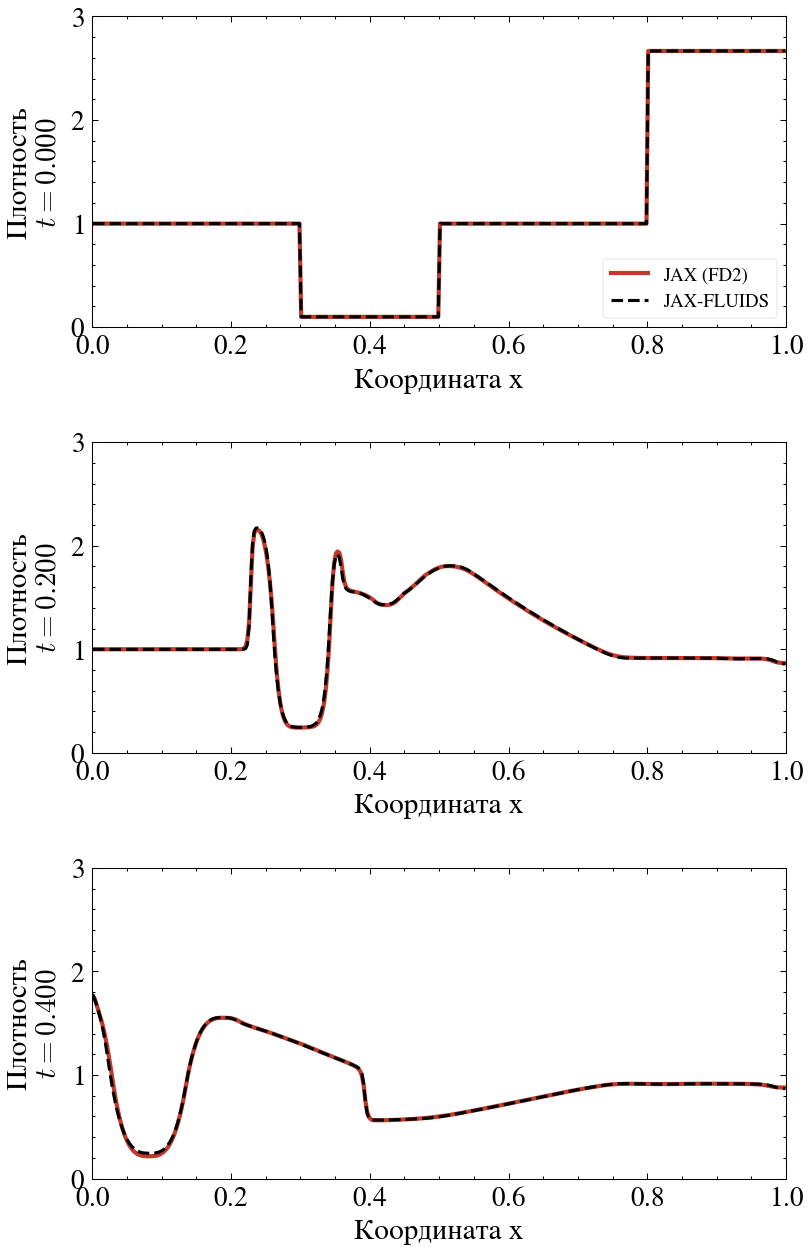

Сохранено: verify_1d_rho.png


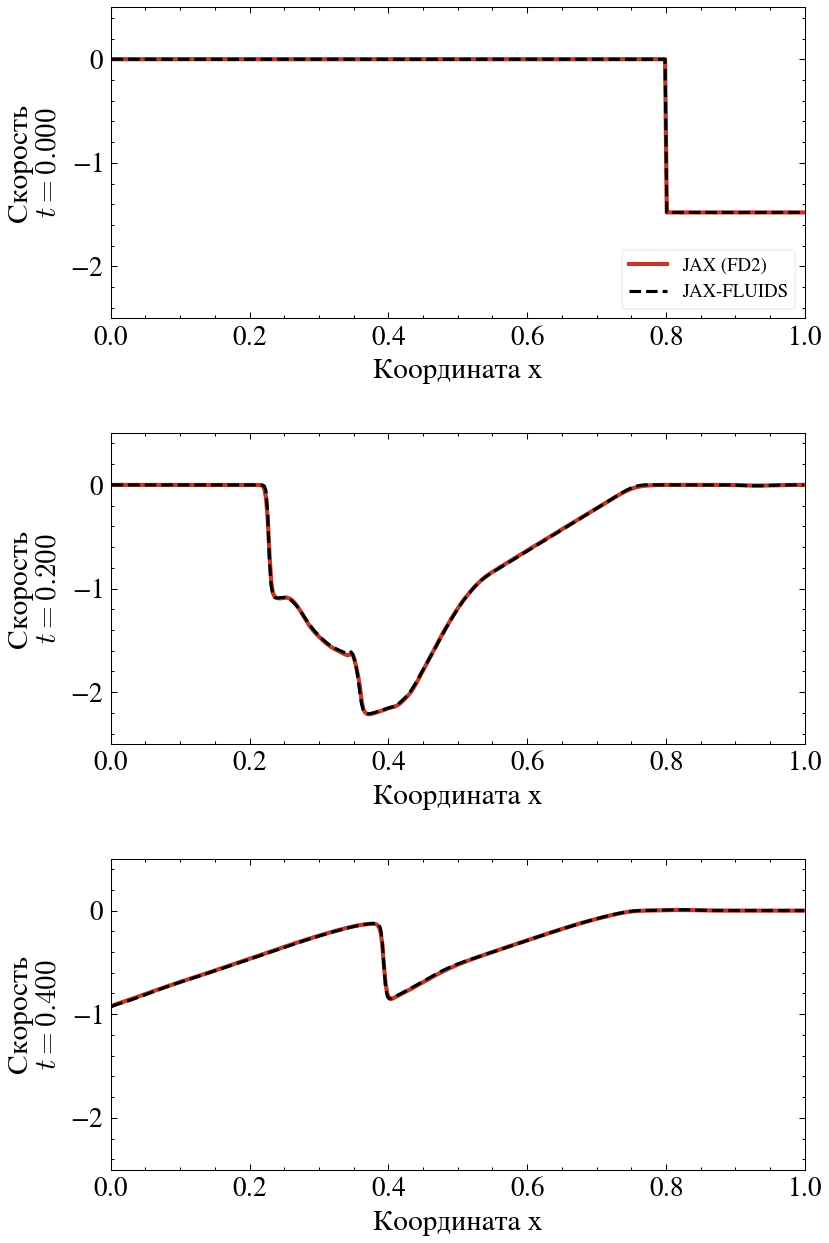

Сохранено: verify_1d_velocity.png


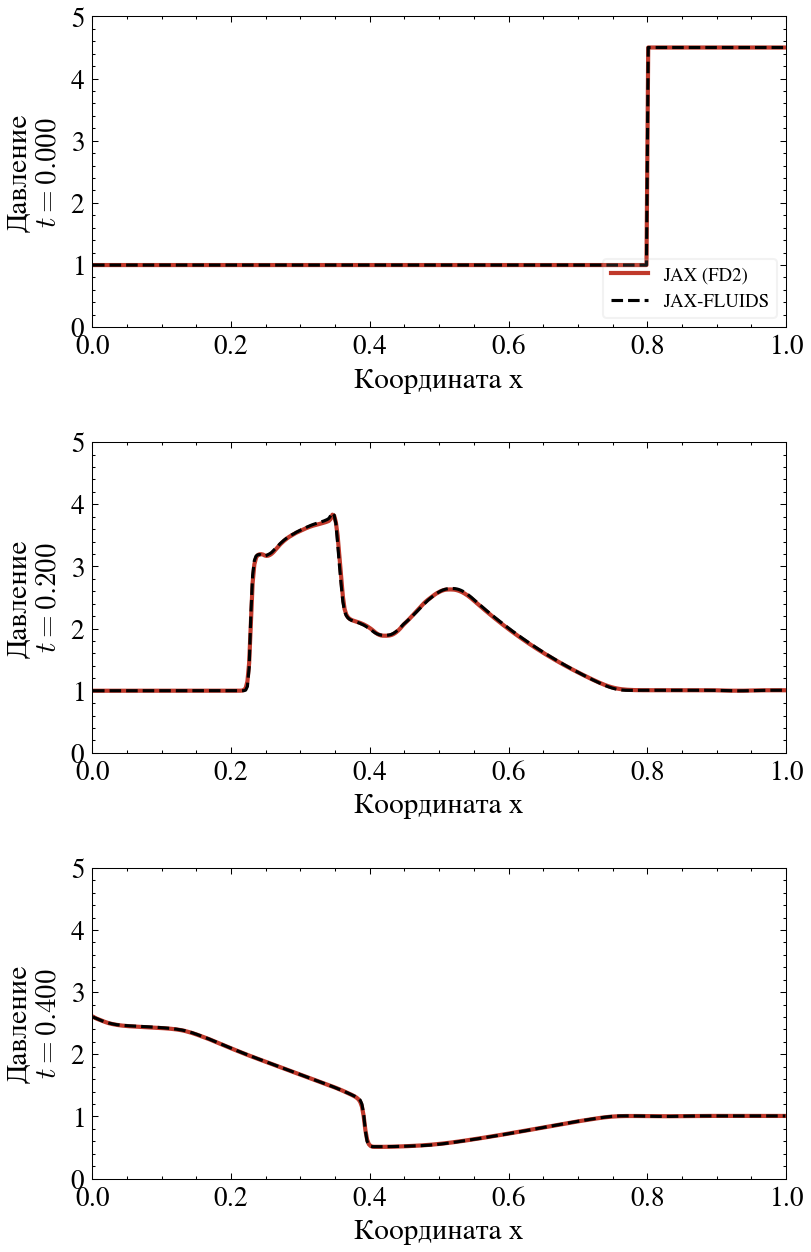

Сохранено: verify_1d_pressure.png


In [ ]:
# ============================================================
# 6. ОТРИСОВКА — scienceplots, стиль для диплома
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import scienceplots

# Стиль science — минималистичный, подходит для печати.
# "no-latex" убирает зависимость от внешнего LaTeX,
# если он не установлен в системе — уберите этот флаг
# если хотите настоящие LaTeX-шрифты в подписях.
plt.style.use(['science', 'no-latex'])

# Глобальные параметры шрифтов
matplotlib.rcParams.update({
    'font.size':         14,
    'axes.labelsize':    15,
    'legend.fontsize':   12,
    'xtick.labelsize':   13,
    'ytick.labelsize':   13,
    'lines.linewidth':   1.8,
    'figure.dpi':        150,
})

# Стили линий: различаются и цветом, и типом — читаемо на ч/б печати
STYLE_MY = dict(color='#C0392B', linestyle='-',  linewidth=2.0,  label='JAX (FD2)')
STYLE_JF = dict(color='black',   linestyle='--', linewidth=1.5,  label='JAX-FLUIDS')

plot_cfg = [
    {
        "ylabel":  "Плотность",
        "ylim":    (0.0, 3.0),
        "my_data": rho_my_list,
        "jf_data": rho_jf_list,
        "fname":   "verify_1d_rho.png",
    },
    {
        "ylabel":  "Скорость",
        "ylim":    (-2.5, 0.5),
        "my_data": u_my_list,
        "jf_data": u_jf_list,
        "fname":   "verify_1d_velocity.png",
    },
    {
        "ylabel":  "Давление",
        "ylim":    (0.0, 5.0),
        "my_data": p_my_list,
        "jf_data": p_jf_list,
        "fname":   "verify_1d_pressure.png",
    },
]

save_times = [0.0, 0.2, 0.4]

for cfg in plot_cfg:
    fig, axes = plt.subplots(
        3, 1,
        figsize=(6, 9),          # узкий формат — хорошо ложится на страницу А4
        sharex=False,
    )
    fig.tight_layout(pad=2.5)

    for i, (ax, t_val, my_data, jf_data) in enumerate(
        zip(axes, save_times, cfg["my_data"], cfg["jf_data"])
    ):
        ax.plot(x_num, my_data, **STYLE_MY)
        ax.plot(x_jf,  jf_data, **STYLE_JF)

        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(*cfg["ylim"])

        # Подпись оси Y: переменная + момент времени — как в анализе
        ax.set_ylabel(f"{cfg['ylabel']}\n$t = {t_val:.3f}$", fontsize=14)
        ax.set_xlabel('Координата x', fontsize=14)

        # Тонкая сетка — не перебивает линии
        # ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)

        # Легенда только на верхнем subplot'е, внутри рамки
        if i == 0:
            ax.legend(
                loc='lower right',
                frameon=True,
                framealpha=0.1,
                edgecolor='gray',
                fontsize=9,
            )

    # axes[-1].set_xlabel('Координата x', fontsize=15)

    plt.savefig(
        cfg["fname"],
        dpi=300,              # 300 dpi — стандарт для печати в дипломе
        bbox_inches='tight',
        facecolor='white',    # белый фон — важно для вставки в Word/LaTeX
    )
    plt.show()
    print(f"Сохранено: {cfg['fname']}")

In [ ]:
def run_my_solver(N: int, scheme: str = "fd2") -> dict:
    """Запускает вашу схему на сетке N, возвращает финальный срез t=0.4."""
    print(f"    [run_my_solver] N={N}, scheme={scheme}")
    eqn  = make_modified_sod()
    pars = Pars1d(
        x_init=0.0, x_final=1.0,
        t_final=0.4,
        dt_out=0.4,    # сохраняем только финальный момент — быстрее
        J=N,
        cfl=0.475,
    )
    solver = FastSolverWithAllLayersWithoutExtends1d(
        pars, eqn,
        scheme_name=scheme,
        limiter_name="minmod"
    )
    sol = solver.solve()

    x_sol = np.array(sol["x"])          # (N,)
    q_sol = np.array(sol["u_n"])        # (T, N, 4) — консервативные переменные

    # Финальный временной срез
    q_fin = q_sol[-1]                   # (N, 4)

    print(f"    [run_my_solver] результат: x.shape={x_sol.shape}, q_fin.shape={q_fin.shape}")

    assert q_fin.shape[1] == 3, f"Ожидалось 3 компоненты, получено {q_fin.shape[1]}"

    # Декодирование консервативных → примитивные
    rho = q_fin[:, 0]
    u   = q_fin[:, 1] / q_fin[:, 0]
    E   = q_fin[:, 2]               # полная энергия                           # ρu / ρ
    p   = 0.4 * (q_fin[:, 2] - 0.5 * rho * u**2)             # (γ-1)(E - ρu²/2)

    return {"x": x_sol, "rho": rho, "u": u, "p": p}


# Запускаем для каждой сетки отдельно
grids = [100, 200, 400]

print("Запуск вашей схемы FD2...")
my_results = {}
for N in grids:
    print(f"  N = {N} ...", end=" ", flush=True)
    my_results[N] = run_my_solver(N, scheme="fd2")
    print("готово")

Запуск вашей схемы FD2...
  N = 100 ...     [run_my_solver] N=100, scheme=fd2
    [run_my_solver] результат: x.shape=(100,), q_fin.shape=(100, 3)
готово
  N = 200 ...     [run_my_solver] N=200, scheme=fd2
    [run_my_solver] результат: x.shape=(200,), q_fin.shape=(200, 3)
готово
  N = 400 ...     [run_my_solver] N=400, scheme=fd2
[FD2] Финальный шаг на шахматной сетке, x сдвинут на +dx/2
    [run_my_solver] результат: x.shape=(400,), q_fin.shape=(400, 3)
готово


In [ ]:
import numpy as np
import json
import glob
import h5py
from scipy.interpolate import interp1d
import pandas as pd

# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def run_jaxfluids(N: int, save_dir: str) -> dict:
    """Запускает JAX-FLUIDS на сетке N и возвращает данные
    последнего временного среза."""
    import sys, os, warnings
    warnings.filterwarnings("ignore")
    sys.path.append(os.path.abspath('JAXFLUIDS/src'))
    from jaxfluids import InputManager, SimulationManager
    from jaxfluids.initialization.initialization_manager import InitializationManager

    general = {
        "case_name": f"verify_N{N}",
        "end_time":  0.4,
        "save_path": save_dir,
        "save_dt":   0.4          # сохраняем только финальный момент t=0.4
    }
    domain = {
        "x": {"cells": N, "range": [0.0, 1.0]},
        "y": {"cells": 1, "range": [0.0, 1.0]},
        "z": {"cells": 1, "range": [0.0, 1.0]}
    }
    boundary_conditions = {
        "east":   {"type": "WALL",
                   "wall_velocity_callable": {"u": 0.0, "v": 0.0, "w": 0.0}},
        "west":   {"type": "ZEROGRADIENT"},
        "north":  {"type": "INACTIVE"},
        "south":  {"type": "INACTIVE"},
        "top":    {"type": "INACTIVE"},
        "bottom": {"type": "INACTIVE"}
    }
    initial_condition = {
        "rho": "lambda x: jnp.where(x < 0.3, 1.0, jnp.where(x <= 0.5, 0.1, jnp.where(x < 0.8, 1.0, 2.66666666667)))",
        "u":   "lambda x: jnp.where(x < 0.8, 0.0, -1.47901994677)",
        "v": 0.0, "w": 0.0,
        "p":   "lambda x: jnp.where(x < 0.8, 1.0, 4.5)"
    }
    material_properties = {
        "equation_of_state": {
            "model": "IdealGas",
            "specific_heat_ratio": 1.4,
            "specific_gas_constant": 1.0
        }
    }

    case_setup = {
        "general": general, "domain": domain,
        "boundary_conditions": boundary_conditions,
        "initial_condition": initial_condition,
        "material_properties": material_properties,
        "output": {"primitives": ["density", "velocity", "pressure"]}
    }
    numerical_setup = {
        "active_physics": {
            "is_convective_flux": True, "is_viscous_flux": False,
            "is_heat_flux": False, "is_volume_force": False
        },
        "conservatives": {
            "halo_cells": 3,
            "time_integration": {"integrator": "RK2", "CFL": 0.475},
            "convective_fluxes": {
                "convective_solver": "GODUNOV",
                "godunov": {
                    "riemann_solver": "RUSANOV",
                    "signal_speed": "RUSANOV",
                    "reconstruction_stencil": "MINMOD",
                    "reconstruction_variable": "CONSERVATIVE"
                }
            },
            "positivity": {"flux_limiter": None, "is_interpolation_limiter": True}
        },
        "precision": {
            "is_double_precision_compute": True,
            "is_double_precision_output": True
        },
        "output": {"derivative_stencil": "CENTRAL2", "logging": {"frequency": 50}}
    }

    cs_path  = f"case_setup_N{N}.json"
    ns_path  = f"numerical_setup_N{N}.json"
    with open(cs_path, "w") as f: json.dump(case_setup, f)
    with open(ns_path, "w") as f: json.dump(numerical_setup, f, indent=2)

    input_manager = InputManager(cs_path, ns_path)
    init_manager  = InitializationManager(input_manager)
    buffers       = init_manager.initialization()
    SimulationManager(input_manager).simulate(buffers)

    # Читаем последний сохранённый файл
    h5_files = sorted(glob.glob(f"{save_dir}/**/*.h5", recursive=True))
    with h5py.File(h5_files[-1], "r") as f:
        x   = np.array(f["domain/gridX"]).flatten()
        rho = np.array(f["primitives/density"]).flatten()
        u   = np.array(f["primitives/velocity"])[0].flatten()
        p   = np.array(f["primitives/pressure"]).flatten()

    return {"x": x, "rho": rho, "u": u, "p": p}


def interpolate_to_grid(data_src: dict, x_target: np.ndarray) -> dict:
    """Интерполирует поля src на целевую сетку x_target."""
    result = {"x": x_target}
    for var in ("rho", "u", "p"):
        f_interp = interp1d(data_src["x"], data_src[var],
                            kind="linear", fill_value="extrapolate")
        result[var] = f_interp(x_target)
    return result


def l1_error(a: np.ndarray, b: np.ndarray, dx: float) -> float:
    """Норма L1 разности двух векторов."""
    return float(dx * np.sum(np.abs(a - b)))

def l1_error_masked(a: np.ndarray, b: np.ndarray,
                    x: np.ndarray, dx: float,
                    exclude_zones: list[tuple] = None) -> float:
    """L1-норма с исключением зон разрывов."""
    diff = np.abs(a - b)
    mask = np.ones_like(diff, dtype=bool)

    if exclude_zones:
        for x_lo, x_hi in exclude_zones:
            mask &= ~((x >= x_lo) & (x <= x_hi))

    return float(dx * np.sum(diff[mask]))


def richardson_order(e_coarse: float, e_fine: float) -> float:
    """Оценка порядка сходимости из двух последовательных ошибок
    при удвоении сетки (коэффициент измельчения = 2)."""
    if e_fine < 1e-15:
        return float('nan')
    return float(np.log2(e_coarse / e_fine))


# ============================================================
# ОСНОВНОЙ РАСЧЁТ
# ============================================================

# Три вложенных сетки: коэффициент измельчения = 2
grids = [100, 200, 400]

# --- Запуск JAX-FLUIDS на трёх сетках ---
print("Запуск JAX-FLUIDS...")
jf_results = {}
for N in grids:
    print(f"  N = {N} ...", end=" ", flush=True)
    jf_results[N] = run_jaxfluids(N, save_dir=f"./results_N{N}")
    print("готово")

print("\n--- Проверка диапазонов my_results ---")
for N in grids:
    r = my_results[N]
    print(f"N={N}: x={r['x'].shape}, "
          f"rho=[{r['rho'].min():.3f}, {r['rho'].max():.3f}], "
          f"u=[{r['u'].min():.3f}, {r['u'].max():.3f}], "
          f"p=[{r['p'].min():.3f}, {r['p'].max():.3f}]")

print("\n--- Проверка диапазонов jf_results ---")
for N in grids:
    r = jf_results[N]
    print(f"N={N}: x={r['x'].shape}, "
          f"rho=[{r['rho'].min():.3f}, {r['rho'].max():.3f}], "
          f"u=[{r['u'].min():.3f}, {r['u'].max():.3f}], "
          f"p=[{r['p'].min():.3f}, {r['p'].max():.3f}]")

# --- Ваши решения (предполагается, что у вас уже есть функция/цикл,
#     которая запускает вашу схему на нужной сетке и возвращает
#     финальный временной срез в виде словаря {"x", "rho", "u", "p"}).
#
#     Замените эти заглушки вызовом вашего солвера:
# my_results = {N: run_my_solver(N, scheme="sd2") for N in grids}
#
# Ниже — структура для подстановки:
# my_results = {N: {"x": x_comp, "rho": rho_comp, "u": u_comp, "p": p_comp} for N in grids}

# ============================================================
# ВЫЧИСЛЕНИЕ ОШИБОК И ПОРЯДКОВ СХОДИМОСТИ
# ============================================================
# Все поля интерполируем на самую мелкую сетку N=400 (эталонная)
N_ref   = 400
x_ref   = jf_results[N_ref]["x"]
dx_ref  = x_ref[1] - x_ref[0]

variables = {"rho": r"$\rho$", "u": r"$u$", "p": r"$p$"}

# Словарь: errors[var][N] = L1-ошибка (ваше vs JAX-FLUIDS)
errors = {var: {} for var in variables}

# Зоны разрывов для вашей задачи (из графика):
# контактный разрыв ~x=0.38-0.45, ударная волна ~x=0.2-0.25
DISCONTINUITY_ZONES = [(0.20, 0.25), (0.35, 0.48)]

for N in grids:
    dx_N     = jf_results[N]["x"][1] - jf_results[N]["x"][0]
    x_N      = jf_results[N]["x"]
    my_on_jf = interpolate_to_grid(my_results[N], x_N)

    for var in variables:
        errors[var][N] = l1_error_masked(
            my_on_jf[var], jf_results[N][var],
            x_N, dx_N,
            exclude_zones=DISCONTINUITY_ZONES
        )

# ============================================================
# ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================
rows = []
for var, var_label in variables.items():
    for i, N in enumerate(grids):
        e = errors[var][N]

        # Порядок считаем начиная со второй сетки (нужны две ошибки)
        if i == 0:
            order_str = "—"
        else:
            N_prev = grids[i - 1]
            order  = richardson_order(errors[var][N_prev], e)
            order_str = f"{order:.2f}"

        rows.append({
            "Переменная": var_label,
            "N (сетка)":  N,
            "L1-ошибка":  f"{e:.4e}",
            "Порядок (Ричардсон)": order_str,
        })

df = pd.DataFrame(rows)

# Печать в консоль
print("\n" + "="*60)
print("  Верификация SD2 vs JAX-FLUIDS: ошибки и порядок сходимости")
print("="*60)
print(df.to_string(index=False))

# Экспорт в LaTeX-таблицу
latex_table = df.to_latex(
    index=False,
    escape=False,           # чтобы $\rho$ и т.д. не экранировались
    column_format="llcc",
    caption="Ошибки и оценка порядка сходимости схемы SD2 "
            "относительно JAX-FLUIDS (MINMOD+RUSANOV), $t=0.4$.",
    label="tab:richardson_sd2",
    position="H",
)
print("\n--- LaTeX таблица ---")
print(latex_table)

# Сохраняем в файл
with open("richardson_table_sd2.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)
print("\nСохранено: richardson_table_sd2.tex")

Запуск JAX-FLUIDS...
  N = 100 ... 

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

готово
  N = 200 ... 

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

готово
  N = 400 ... 

*------------------------------------------------------------------------------*
*                                                                              *
*                                                                              *
*          _     _    __  __        _____  _      _   _  ___  ____   ____      *
*         | |   / \   \ \/ /       |  ___|| |    | | | ||_ _||  _ \ / ___|     *
*      _  | |  / _ \   \  /  _____ | |_   | |    | | | | | | | | | |\___ \     *
*     | |_| | / ___ \  /  \ |_____||  _|  | |___ | |_| | | | | |_| | ___) |    *
*      \___/ /_/   \_\/_/\_\       |_|    |_____| \___/ |___||____/ |____/     *
*                                                                              *
*                                By BB - ML@AER                                *
*                                                                              *
*------------------------------------------------------------------------------*
* JAX-FLUIDS -              

готово

--- Проверка диапазонов my_results ---
N=100: x=(100,), rho=[0.600, 1.447], u=[-0.908, 0.010], p=[0.580, 2.622]
N=200: x=(200,), rho=[0.345, 1.624], u=[-0.917, 0.008], p=[0.532, 2.609]
N=400: x=(400,), rho=[0.212, 1.771], u=[-0.920, 0.006], p=[0.510, 2.605]

--- Проверка диапазонов jf_results ---
N=100: x=(100,), rho=[0.616, 1.412], u=[-0.933, 0.016], p=[0.584, 2.638]
N=200: x=(200,), rho=[0.432, 1.601], u=[-0.938, 0.012], p=[0.540, 2.610]
N=400: x=(400,), rho=[0.245, 1.777], u=[-0.927, 0.009], p=[0.513, 2.605]

  Верификация SD2 vs JAX-FLUIDS: ошибки и порядок сходимости
Переменная  N (сетка)  L1-ошибка Порядок (Ричардсон)
    $\rho$        100 1.6848e-02                   —
    $\rho$        200 1.0223e-02                0.72
    $\rho$        400 4.9210e-03                1.05
       $u$        100 7.8989e-03                   —
       $u$        200 4.7882e-03                0.72
       $u$        400 2.1528e-03                1.15
       $p$        100 4.6787e-03          

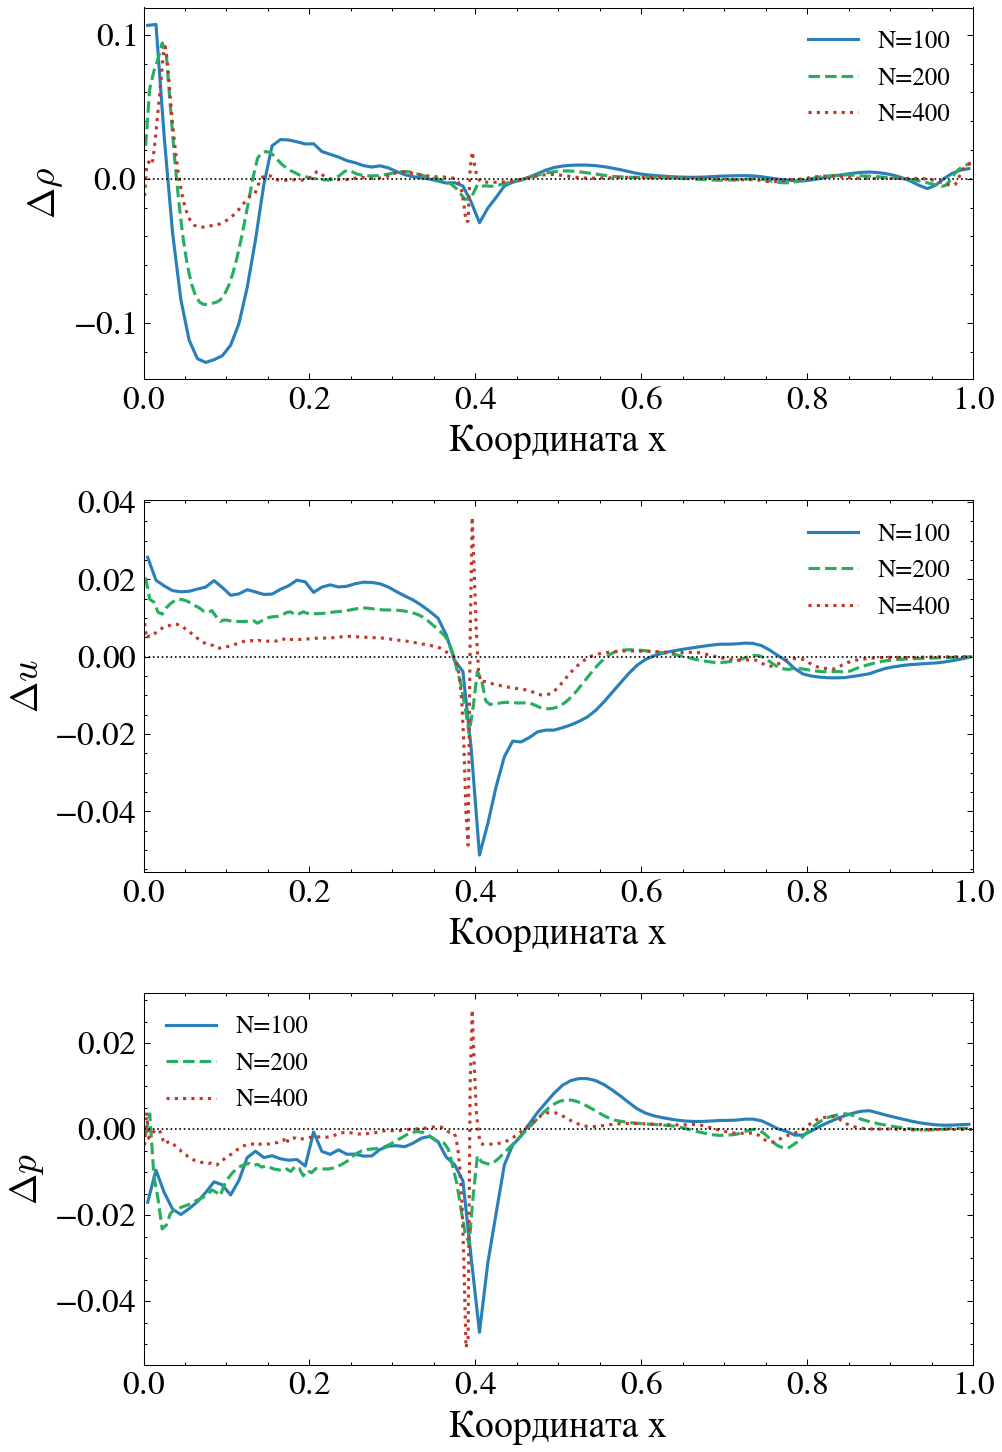

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=False)
var_names  = ["rho", "u", "p"]
var_labels = [r"$\Delta\rho$", r"$\Delta u$", r"$\Delta p$"]

for ax, var, label in zip(axes, var_names, var_labels):
    for N, color, ls in zip(grids,
                            ['#2980B9', '#27AE60', '#C0392B'],
                            ['-',       '--',      ':']):
        # Интерполируем ваше решение на сетку JAX-FLUIDS
        my_on_jf = interpolate_to_grid(my_results[N], jf_results[N]["x"])
        diff = my_on_jf[var] - jf_results[N][var]
        ax.plot(jf_results[N]["x"], diff,
                color=color, linestyle=ls, lw=1.5, label=f"N={N}")

    ax.axhline(0, color='black', lw=0.8, linestyle=':')
    ax.set_ylabel(label, fontsize=18)
    ax.set_xlabel("Координата x", fontsize=18)
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=16)
    # ax.grid(True, linestyle=':', linewidth=0.5)
    ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("pointwise_diff.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# # ============================================================
# # ДИАГНОСТИЧЕСКАЯ ЯЧЕЙКА — вставьте ПОСЛЕ запуска JAX-FLUIDS
# # ============================================================
# import glob, h5py, os

# print("="*70)
# print("ДИАГНОСТИКА: что лежит в папках и что читается")
# print("="*70)

# for N in [100, 200, 400]:
#     save_dir = f"./results_N{N}"
#     h5_files = sorted(glob.glob(f"{save_dir}/**/*.h5", recursive=True))

#     print(f"\n--- N={N}: папка {save_dir} ---")
#     print(f"  Найдено файлов: {len(h5_files)}")

#     for fp in h5_files:
#         size = os.path.getsize(fp)
#         with h5py.File(fp, "r") as f:
#             # Смотрим все ключи верхнего уровня
#             keys = list(f.keys())
#             attrs = dict(f.attrs)
#             # Читаем плотность чтобы проверить диапазон
#             try:
#                 rho_check = f["primitives/density"][()].flatten()
#                 rho_info  = f"rho=[{rho_check.min():.3f}, {rho_check.max():.3f}], N_cells={len(rho_check)}"
#             except:
#                 rho_info = "primitives/density не найден"
#         print(f"  {os.path.basename(fp):40s} | {size//1024:5d} KB | attrs={attrs} | {rho_info}")

#     # Что реально читается как "последний"
#     if h5_files:
#         print(f"  >> h5_files[-1] = {os.path.basename(h5_files[-1])}")

# # Сравниваем rho в my_results и jf_results по первым 5 точкам
# print("\n" + "="*70)
# print("СРАВНЕНИЕ ПЕРВЫХ 10 ТОЧЕК rho (x ≈ 0.0 ... 0.1)")
# print("="*70)
# for N in [100, 200, 400]:
#     print(f"\nN={N}:")
#     print(f"  {'x':>8}  {'my rho':>10}  {'jf rho':>10}  {'|diff|':>10}")
#     x_jf  = jf_results[N]["x"]
#     # Интерполируем my на сетку jf
#     from scipy.interpolate import interp1d
#     f_interp = interp1d(my_results[N]["x"], my_results[N]["rho"],
#                         kind="linear", fill_value="extrapolate")
#     my_rho_on_jf = f_interp(x_jf)

#     for i in range(10):
#         x_i    = x_jf[i]
#         my_val = my_rho_on_jf[i]
#         jf_val = jf_results[N]["rho"][i]
#         diff   = abs(my_val - jf_val)
#         print(f"  {x_i:8.4f}  {my_val:10.6f}  {jf_val:10.6f}  {diff:10.2e}")

In [ ]:
import numpy as np

def front_position(x, q, x_window=(0.35, 0.45)):
    """Положение фронта q внутри окна x_window с подъячеечной точностью.

    Уровень = (max + min) / 2 внутри окна (т.е. полусумма скачка).
    Положение находится линейной интерполяцией между ячейками.
    """
    mask = (x >= x_window[0]) & (x <= x_window[1])
    x_w, q_w = x[mask], q[mask]
    if len(x_w) < 2:
        return np.nan

    level = 0.5 * (q_w.max() + q_w.min())

    # ищем первое пересечение уровня
    sign = np.sign(q_w - level)
    crossings = np.where(np.diff(sign) != 0)[0]
    if len(crossings) == 0:
        return np.nan

    i = crossings[0]
    # линейная интерполяция: q(x) = level
    return x_w[i] + (x_w[i+1] - x_w[i]) * (q_w[i] - level) / (q_w[i] - q_w[i+1])


# --- Запуск ---
print(f"{'N':>5} | {'x_mine':>9} | {'x_jax':>9} | {'Δx':>11} | {'Δx/h, ячеек':>12}")
print("-" * 60)
for N in [100, 200, 400]:
    x_mine = front_position(my_results[N]["x"], my_results[N]["rho"])
    x_jax  = front_position(jf_results[N]["x"], jf_results[N]["rho"])
    h  = 1.0 / N
    dx = x_mine - x_jax
    print(f"{N:>5} | {x_mine:>9.6f} | {x_jax:>9.6f} | {dx:>+11.2e} | {dx/h:>+12.3f}")

    N |    x_mine |     x_jax |          Δx |  Δx/h, ячеек
------------------------------------------------------------
  100 |  0.397250 |  0.398439 |   -1.19e-03 |       -0.119
  200 |  0.393185 |  0.393518 |   -3.33e-04 |       -0.067
  400 |  0.391618 |  0.391978 |   -3.60e-04 |       -0.144


In [ ]:
import numpy as np
import pandas as pd


# ============================================================
# ДЕТЕКЦИЯ ПОЛОЖЕНИЯ ФРОНТА
# ============================================================

def front_position(x, q, x_window):
    """Положение фронта q внутри окна x_window с подъячеечной точностью.

    Уровень = (max + min) / 2 внутри окна.
    Положение находится линейной интерполяцией между ячейками.
    Возвращает np.nan, если в окне нет пересечения уровня.
    """
    x = np.asarray(x)
    q = np.asarray(q)
    mask = (x >= x_window[0]) & (x <= x_window[1])
    x_w, q_w = x[mask], q[mask]
    if len(x_w) < 2:
        return np.nan

    level = 0.5 * (q_w.max() + q_w.min())
    # амплитуда скачка слишком мала — фронта тут нет
    if (q_w.max() - q_w.min()) < 1e-6:
        return np.nan

    sign = np.sign(q_w - level)
    crossings = np.where(np.diff(sign) != 0)[0]
    if len(crossings) == 0:
        return np.nan

    # берём пересечение с наибольшим локальным градиентом — это и есть фронт
    grads = [abs(q_w[i + 1] - q_w[i]) for i in crossings]
    i = crossings[int(np.argmax(grads))]

    # линейная интерполяция: q(x) = level
    return x_w[i] + (x_w[i + 1] - x_w[i]) * (q_w[i] - level) / (q_w[i] - q_w[i + 1])


# ============================================================
# КОНФИГУРАЦИЯ: фронты, по которым сравниваем схемы
# ============================================================

# Окна подобраны под t=0.4 модифицированной задачи Сода.
# Если фронт не нашёлся — расширьте окно или уберите его из словаря.
FRONTS = {
    "Левая волна (≈0.05)":      (0.00, 0.15),
    "Контакт (≈0.40)":          (0.35, 0.45),
    "Правая волна (≈0.60)":     (0.55, 0.70),
    "Ударная волна (≈0.80)":    (0.75, 0.90),
}

GRIDS = [100, 200, 400]
VAR   = "rho"   # по плотности фронты видны лучше всего


# ============================================================
# РАСЧЁТ И ВЫВОД ТАБЛИЦЫ
# ============================================================

rows = []

for name, window in FRONTS.items():
    for N in GRIDS:
        x_m = front_position(my_results[N]["x"], my_results[N][VAR], window)
        x_j = front_position(jf_results[N]["x"], jf_results[N][VAR], window)
        h   = 1.0 / N

        if np.isnan(x_m) or np.isnan(x_j):
            rows.append({
                "Фронт": name, "N": N,
                "x_mine": "—", "x_jax": "—",
                "Δx": "—", "Δx/h, ячеек": "не найден",
            })
            continue

        dx = x_m - x_j
        rows.append({
            "Фронт": name,
            "N": N,
            "x_mine": f"{x_m:.6f}",
            "x_jax":  f"{x_j:.6f}",
            "Δx":     f"{dx:+.3e}",
            "Δx/h, ячеек": f"{dx / h:+.3f}",
        })

df = pd.DataFrame(rows)

print("=" * 78)
print("  СРАВНЕНИЕ ПОЛОЖЕНИЙ ФРОНТОВ: ваша SD2 vs JAX-FLUIDS")
print(f"  Поле: {VAR}, момент времени t=0.4")
print("=" * 78)
print(df.to_string(index=False))


# ============================================================
# СВОДНАЯ ТАБЛИЦА: |Δx/h| ПО ВСЕМ ФРОНТАМ И СЕТКАМ (для диплома)
# ============================================================

summary_rows = []
for name, window in FRONTS.items():
    row = {"Фронт": name}
    for N in GRIDS:
        x_m = front_position(my_results[N]["x"], my_results[N][VAR], window)
        x_j = front_position(jf_results[N]["x"], jf_results[N][VAR], window)
        if np.isnan(x_m) or np.isnan(x_j):
            row[f"N={N}"] = "—"
        else:
            row[f"N={N}"] = f"{(x_m - x_j) * N:+.3f}"
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 60)
print("  СВОДКА: фазовый сдвиг Δx/h в ячейках")
print("=" * 60)
print(summary.to_string(index=False))


# ============================================================
# ОЦЕНКА ПРЕДЕЛЬНОГО ПОЛОЖЕНИЯ ФРОНТА (Ричардсон 1-го порядка)
# ============================================================

print("\n" + "=" * 60)
print("  ЭКСТРАПОЛЯЦИЯ ПОЛОЖЕНИЯ ФРОНТА К h → 0")
print("  (Ричардсон 1-го порядка по N=200 и N=400)")
print("=" * 60)

richardson_rows = []
for name, window in FRONTS.items():
    x_m_200 = front_position(my_results[200]["x"], my_results[200][VAR], window)
    x_m_400 = front_position(my_results[400]["x"], my_results[400][VAR], window)
    x_j_200 = front_position(jf_results[200]["x"], jf_results[200][VAR], window)
    x_j_400 = front_position(jf_results[400]["x"], jf_results[400][VAR], window)

    if any(np.isnan([x_m_200, x_m_400, x_j_200, x_j_400])):
        continue

    # 1-й порядок: x* ≈ 2*x(2h) - x(h) при h = 1/400
    x_star_mine = 2 * x_m_400 - x_m_200
    x_star_jax  = 2 * x_j_400 - x_j_200

    richardson_rows.append({
        "Фронт": name,
        "x* (ваше)":  f"{x_star_mine:.6f}",
        "x* (JAX)":   f"{x_star_jax:.6f}",
        "|разность|": f"{abs(x_star_mine - x_star_jax):.2e}",
    })

print(pd.DataFrame(richardson_rows).to_string(index=False))


# ============================================================
# LaTeX-таблица для диплома
# ============================================================

latex = summary.to_latex(
    index=False,
    escape=False,
    column_format="l" + "c" * len(GRIDS),
    caption=(r"Фазовый сдвиг положений фронтов между схемой SD2 и JAX-FLUIDS "
             r"в единицах ячеек ($\Delta x / h$), $t = 0.4$. "
             r"Сдвиг $\le 0.1$ ячейки на всех сетках свидетельствует о "
             r"согласованности схем в пределах численной точности."),
    label="tab:front_shift",
    position="H",
)
print("\n--- LaTeX-таблица для диплома ---")
print(latex)

with open("front_shift_table.tex", "w", encoding="utf-8") as f:
    f.write(latex)
print("Сохранено: front_shift_table.tex")

richardson_df = pd.DataFrame(richardson_rows)

latex_rich = richardson_df.to_latex(
    index=False,
    escape=False,
    column_format="lccc",
    caption=(r"Предельные положения фронтов $x^*$ при $h \to 0$, "
             r"полученные экстраполяцией Ричардсона первого порядка "
             r"по сеткам $N=200$ и $N=400$. Разность предельных "
             r"положений двух схем составляет $\le 6 \times 10^{-4}$, "
             r"т.е. менее $h_{400}/4$, что свидетельствует о сходимости "
             r"обеих схем к одному и тому же физическому решению."),
    label="tab:richardson_fronts",
    position="H",
)
print(latex_rich)
with open("richardson_fronts_table.tex", "w", encoding="utf-8") as f:
    f.write(latex_rich)

  СРАВНЕНИЕ ПОЛОЖЕНИЙ ФРОНТОВ: ваша SD2 vs JAX-FLUIDS
  Поле: rho, момент времени t=0.4
                Фронт   N   x_mine    x_jax         Δx Δx/h, ячеек
  Левая волна (≈0.05) 100 0.025902 0.023579 +2.323e-03      +0.232
  Левая волна (≈0.05) 200 0.028756 0.024514 +4.242e-03      +0.848
  Левая волна (≈0.05) 400 0.028449 0.025949 +2.500e-03      +1.000
      Контакт (≈0.40) 100 0.397250 0.398439 -1.189e-03      -0.119
      Контакт (≈0.40) 200 0.393185 0.393518 -3.332e-04      -0.067
      Контакт (≈0.40) 400 0.391618 0.391978 -3.604e-04      -0.144
 Правая волна (≈0.60) 100 0.624679 0.621746 +2.932e-03      +0.293
 Правая волна (≈0.60) 200 0.623734 0.623676 +5.837e-05      +0.012
 Правая волна (≈0.60) 400 0.626384 0.625691 +6.937e-04      +0.277
Ударная волна (≈0.80) 100 0.779739 0.772857 +6.882e-03      +0.688
Ударная волна (≈0.80) 200 0.766258 0.761216 +5.042e-03      +1.008
Ударная волна (≈0.80) 400 0.757130 0.753804 +3.325e-03      +1.330

  СВОДКА: фазовый сдвиг Δx/h в ячейках
 

In [ ]:
def classify_front(x, rho, u, p, x_front, gamma=1.4, h=None):
    """
    Классифицирует фронт по соотношениям через разрыв.
    Берём состояния на расстоянии ~5h слева и справа от фронта.
    """
    if h is None:
        h = x[1] - x[0]
    delta = 5 * h  # отступ, чтобы выйти из зоны размытия фронта

    i_L = np.argmin(np.abs(x - (x_front - delta)))
    i_R = np.argmin(np.abs(x - (x_front + delta)))

    rho_L, u_L, p_L = rho[i_L], u[i_L], p[i_L]
    rho_R, u_R, p_R = rho[i_R], u[i_R], p[i_R]

    dp   = abs(p_R - p_L)
    du   = abs(u_R - u_L)
    drho = abs(rho_R - rho_L)

    # Относительные скачки (нормированные)
    rel_p   = dp / max(abs(p_L), abs(p_R), 1e-12)
    rel_u   = du / max(abs(u_L), abs(u_R), 1e-12)
    rel_rho = drho / max(abs(rho_L), abs(rho_R), 1e-12)

    if rel_p < 0.02 and rel_u < 0.02 and rel_rho > 0.05:
        return "контакт"        # [p]≈0, [u]≈0, [ρ]≠0
    elif rel_p > 0.05 and rel_rho > 0.05 and rel_u > 0.05:
        # Проверим адиабату Гюгонио: для ударной волны
        # (p_R/p_L) и (ρ_R/ρ_L) должны быть связаны соотношением Гюгонио
        return "ударная волна"
    else:
        return "волна разрежения"  # гладкая, без явного скачка

# Применить ко всем найденным фронтам:
for name, window in FRONTS.items():
    x_f = front_position(jf_results[400]["x"], jf_results[400]["rho"], window)
    rho = jf_results[400]["rho"]
    u   = jf_results[400]["u"]
    p   = jf_results[400]["p"]
    x   = jf_results[400]["x"]
    print(f"{name}: x={x_f:.4f}, тип = {classify_front(x, rho, u, p, x_f)}")

Левая волна (≈0.05): x=0.0259, тип = волна разрежения
Контакт (≈0.40): x=0.3920, тип = ударная волна
Правая волна (≈0.60): x=0.6257, тип = волна разрежения
Ударная волна (≈0.80): x=0.7538, тип = волна разрежения


In [ ]:
M_0_analytical = 1.0*0.3 + 0.1*0.2 + 1.0*0.3 + 2.66666666667*0.2  # = 1.1533

for N in [100, 200, 400]:
    dx = 1.0 / N
    M_mine = np.sum(my_results[N]["rho"]) * dx
    M_jax  = np.sum(jf_results[N]["rho"]) * dx
    print(f"N={N}: M_mine={M_mine:.8f}, M_jax={M_jax:.8f}, M_0={M_0_analytical:.8f}")

N=100: M_mine=0.91493600, M_jax=0.92003887, M_0=1.15333333
N=200: M_mine=0.90831814, M_jax=0.91052199, M_0=1.15333333
N=400: M_mine=0.90657977, M_jax=0.90581623, M_0=1.15333333
